#**Image Classification with Convolutional Neural Network.**

In [1]:
import os
print(os.listdir('/content'))

['.config', 'SignLanguageDetection.zip', 'sample_data']


In [2]:
import zipfile

with zipfile.ZipFile('/content/SignLanguageDetection.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [3]:
import os
print(os.listdir('/content'))

['.config', 'Sign Language Detection', 'SignLanguageDetection.zip', 'sample_data']


In [4]:
print(os.listdir('/content/Sign Language Detection'))

['Train', 'Dataset-Description-6.txt', 'Test']


##**Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.**

###**1. Data Understanding, Analysis, Visualization and Cleaning:**



####• What does the dataset represent? Provide a brief description.

  > This dataset represents a multi-class image classification problem focused on Bengali Sign Language recognition. It consists of images of hand gestures corresponding to different sign language symbols. Each image is labeled with a numerical class (0–37), representing a total of 38 categories. The objective is to train a Convolutional Neural Network (CNN) to accurately classify each image into its corresponding sign class.

####• How many total images are in the dataset?
>The dataset contains a total of 11061 images, 11058 images in train set and 3 images in test set. The dataset is highly skewed towards the training set, with very few test samples provided.

In [5]:
import os

train_path = "/content/Sign Language Detection/Train"
test_path = "/content/Sign Language Detection/Test"

# Valid image extensions
valid_extensions = ('.jpg', '.jpeg', '.png')

def count_images(folder_path):
    total = 0

    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)

        # Case 1: class folders
        if os.path.isdir(item_path):
            images = [f for f in os.listdir(item_path) if f.lower().endswith(valid_extensions)]
            total += len(images)

        # Case 2: images directly inside folder
        elif item.lower().endswith(valid_extensions):
            total += 1

    return total

train_count = count_images(train_path)
test_count = count_images(test_path)

total_images = train_count + test_count

print("Train images:", train_count)
print("Test images:", test_count)
print("Total images:", total_images)

Train images: 11058
Test images: 3
Total images: 11061


####• What is the distribution of images across different classes?
> The distribution of images across classes is largely uniform, with most classes containing approximately 285 to 300 images. However, one class has a noticeably lower count of around 246 images, indicating a slight imbalance. Overall, the dataset can be considered relatively balanced .Since most classes contain a similar number of images, the dataset is relatively balanced, which helps prevent bias toward specific classes during training.

Class-wise image distribution:
Class 0: 293 | Class 1: 294 | Class 2: 298 | Class 3: 286 | Class 4: 246 | Class 5: 294 | Class 6: 291 | Class 7: 289 | Class 8: 297 | Class 9: 292 | Class 10: 298 | Class 11: 291 | Class 12: 284 | Class 13: 286 | Class 14: 277 | Class 15: 294 | Class 16: 298 | Class 17: 293 | Class 18: 294 | Class 19: 295 | Class 20: 293 | Class 21: 293 | Class 22: 300 | Class 23: 292 | Class 24: 297 | Class 25: 294 | Class 26: 292 | Class 27: 293 | Class 28: 291 | Class 29: 292 | Class 30: 292 | Class 31: 295 | Class 32: 288 | Class 33: 295 | Class 34: 290 | Class 35: 286 | Class 36: 289 | Class 37: 296


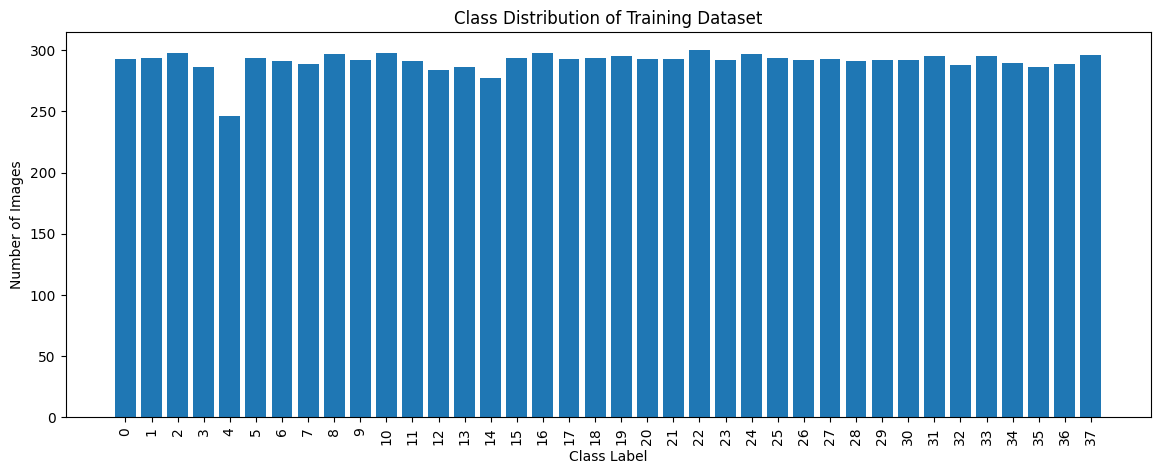

In [6]:
import os
import matplotlib.pyplot as plt


train_path = "/content/Sign Language Detection/Train"
test_path = "/content/Sign Language Detection/Test"
valid_extensions = ('.jpg', '.jpeg', '.png')
class_counts = {}

# Count images per class
for class_name in sorted(os.listdir(train_path), key=lambda x: int(x)):
    class_folder = os.path.join(train_path, class_name)

    if os.path.isdir(class_folder):
        images = [
            f for f in os.listdir(class_folder)
            if f.lower().endswith(valid_extensions)
        ]
        class_counts[class_name] = len(images)

# Print class distribution horizontally
print("Class-wise image distribution:")
print(" | ".join([f"Class {cls}: {count}" for cls, count in class_counts.items()]))

# Plot class distribution
plt.figure(figsize=(14, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Training Dataset")
plt.show()

###Corrputed image detection and cleaning

In [7]:
from PIL import Image
import os

train_path = "/content/Sign Language Detection/Train"
valid_extensions = ('.jpg', '.jpeg', '.png')

corrupted_images = []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(valid_extensions):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                corrupted_images.append(file_path)

print("Number of corrupted images found:", len(corrupted_images))

Number of corrupted images found: 266


In [8]:
deleted = 0

for img_path in corrupted_images:
    try:
        os.remove(img_path)
        deleted += 1
    except Exception as e:
        print("Failed:", img_path)

print("Deleted corrupted images:", deleted)

Deleted corrupted images: 266


In [9]:
train_count = count_images(train_path)
test_count = count_images(test_path)

print("Train images after cleaning:", train_count)
print("Test images:", test_count)
print("Total images:", train_count + test_count)

Train images after cleaning: 10792
Test images: 3
Total images: 10795


####• How is the dataset split into training and validation sets? Justify your choice.

>Since the original dataset contained only 3 images in the provided test folder.Therefore, after removing corrupted images from the training directory, the cleaned training dataset was manually split into training, validation, and test subsets using a 70:20:10 ratio.

This produced 7,536 training images, 2,161 validation images, and 1,095 test images across 38 classes. The 70% training split provides enough data for model learning, the 20% validation split is used to monitor training performance and detect overfitting, and the 10% test split is kept separate for final unbiased evaluation.

In [10]:
import os
import shutil
import random

original_dir = "/content/Sign Language Detection/Train"
base_dir = "/content/split_dataset"

# Step 1: remove old split (VERY IMPORTANT)
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Step 2: create new folders
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

# Step 3: split dataset
for class_name in os.listdir(original_dir):
    class_path = os.path.join(original_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        random.shuffle(images)

        total = len(images)

        train_split = int(0.7 * total)
        val_split = int(0.9 * total)

        train_imgs = images[:train_split]
        val_imgs = images[train_split:val_split]
        test_imgs = images[val_split:]

        for split_dir, img_list in zip(
            [train_dir, val_dir, test_dir],
            [train_imgs, val_imgs, test_imgs]
        ):
            class_split_path = os.path.join(split_dir, class_name)
            os.makedirs(class_split_path)

            for img in img_list:
                shutil.copy(
                    os.path.join(class_path, img),
                    os.path.join(class_split_path, img)
                )

print("Split done")

Split done


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    "/content/split_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    "/content/split_dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    "/content/split_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
print(f"Training images: {train_generator.samples}")
print(f"Validation images: {val_generator.samples}")
print(f"Test images: {test_generator.samples}")


Found 7536 images belonging to 38 classes.
Found 2161 images belonging to 38 classes.
Found 1095 images belonging to 38 classes.
Training images: 7536
Validation images: 2161
Test images: 1095


####• What preprocessing techniques (e.g., resizing, normalization) were applied?
 >The preprocessing techniques applied include resizing and normalization. All images are resized to 224×224 pixels, pixel values are normalized by scaling them from the range 0–255 to 0–1 using a rescaling factor of 1/255. These preprocessing steps ensure consistent input size and improve training stability

####• What data generators, if any, were used for preprocessing and augmentation?
>Keras ImageDataGenerator was used to load and preprocess the images from the manually created train, validation, and test directories. It was configured with rescale=1./255 for normalization. No validation split was applied inside ImageDataGenerator because the dataset had already been manually split into separate train, validation, and test folders.

####• If data augmentation was applied, provide visualizations of sample augmented images.
>Data augmentation is not applied at this phase of the project. Therefore, no augmented image visualizations are provided. Augmentation techniques will be explored in later stages to improve model generalization and reduce overfitting.

###**2. Design, Train, and Evaluate a Baseline Model:**

###2.1  Model Architecture::
    • Building a baseline CNN model with the following structure:

    – Three Convolutional layers, each followed by pooling layers.

    – Three fully connected layers (FCN)

    – An output layer suitable for classification.

    • – Kernel Sizes

    – Number of Filters

    – Activation Functions

    model summary.

In [16]:
#BUILDING THE BASELINE CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(224,224,3)))

# Convolutional Block 1
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(38, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,288,294 (85.02 MB)

 Trainable params: 22,288,294 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN model consists of three convolutional layers, each followed by a max-pooling layer. The convolutional layers use 3×3 kernels with 32, 64, and 128 filters respectively. ReLU activation is used in the convolutional and fully connected layers to introduce non-linearity. After feature extraction, the output is flattened into a one-dimensional vector and passed through three fully connected layers with 256, 128, and 64 neurons. The final output layer contains 38 neurons with softmax activation, matching the 38 sign language classes. The model contains 22,288,294 trainable parameters, with most parameters concentrated in the first dense layer after flattening. This makes the baseline model relatively large and computationally expensive, but suitable as an initial reference model.

###2.2 Model Training:
>• Train the baseline model for an appropriate number of epochs.

>• Plot the training vs validation loss curves over epochs.


In [17]:
#COMPILE THE MODEL
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

baseline_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_baseline_model.keras",
        monitor='val_loss',
        save_best_only=True
    )
]

In [19]:
#TRAIN THE MODEL
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=baseline_callbacks
)

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.0701 - loss: 3.4998 - val_accuracy: 0.1564 - val_loss: 3.0854
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.2481 - loss: 2.6711 - val_accuracy: 0.3346 - val_loss: 2.3093
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.4656 - loss: 1.8180 - val_accuracy: 0.4725 - val_loss: 1.7591
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.6388 - loss: 1.1563 - val_accuracy: 0.5234 - val_loss: 1.6174
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.7759 - loss: 0.7002 - val_accuracy: 0.5650 - val_loss: 1.6272
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.8522 - loss: 0.4446 - val_accuracy: 0.5835 - val_loss: 1.8451
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.9175 - loss: 0.2576 - val_accuracy: 0.5803 - val_loss: 2.2752


###Basline training plots

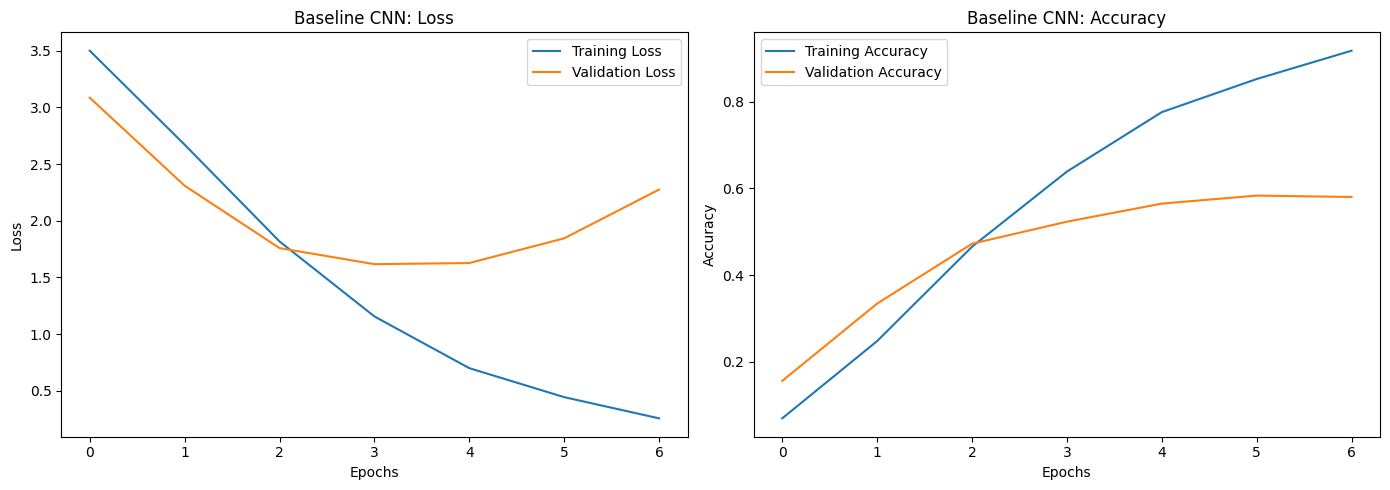

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline CNN: Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline CNN: Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 2.3 Model Evaluation:
>• Evaluate the model using appropriate metrics (e.g. accuracy, precision,
recall and F-1 score).

>• Perform inference on sample images and plot the result.

>• Discuss key observations about model performance.



In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = val_generator.classes

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
              precision    recall  f1-score   support

           0       0.47      0.61      0.53        57
           1       0.76      0.64      0.69        58
           2       0.57      0.52      0.54        58
           3       0.51      0.67      0.58        57
           4       0.56      0.41      0.47        56
           5       0.40      0.52      0.45        56
           6       0.45      0.61      0.52        54
           7       0.22      0.53      0.31        58
           8       0.62      0.59      0.60        58
           9       0.61      0.33      0.43        57
          10       0.24      0.24      0.24        58
          11       0.29      0.43      0.35        58
          12       0.60      0.71      0.65        58
          13       0.62      0.35      0.45        57
          14       0.73      0.47      0.57        57
          15       0.66      0.40      0.49        58
          16       0.53      0.35      0.

test evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.5808 - loss: 1.4474
Test Accuracy: 0.5808219313621521
Test Loss: 1.4473886489868164


The baseline CNN achieved a validation accuracy of approximately 58% with macro and weighted F1-scores near 0.52. When evaluated on the separate test set, the model achieved a test accuracy of 58.08% with a test loss of 1.4474. Training accuracy increased significantly faster than validation accuracy, while validation loss began increasing after several epochs, indicating overfitting. This overfitting likely occurred because the model contains more than 22 million trainable parameters while the dataset size is relatively limited. In addition, no regularization techniques such as dropout, batch normalization, or data augmentation were used in the baseline architecture. Despite the overfitting, the test accuracy remained close to the validation accuracy, suggesting that the validation results reasonably reflect the model’s generalization performance on unseen data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step


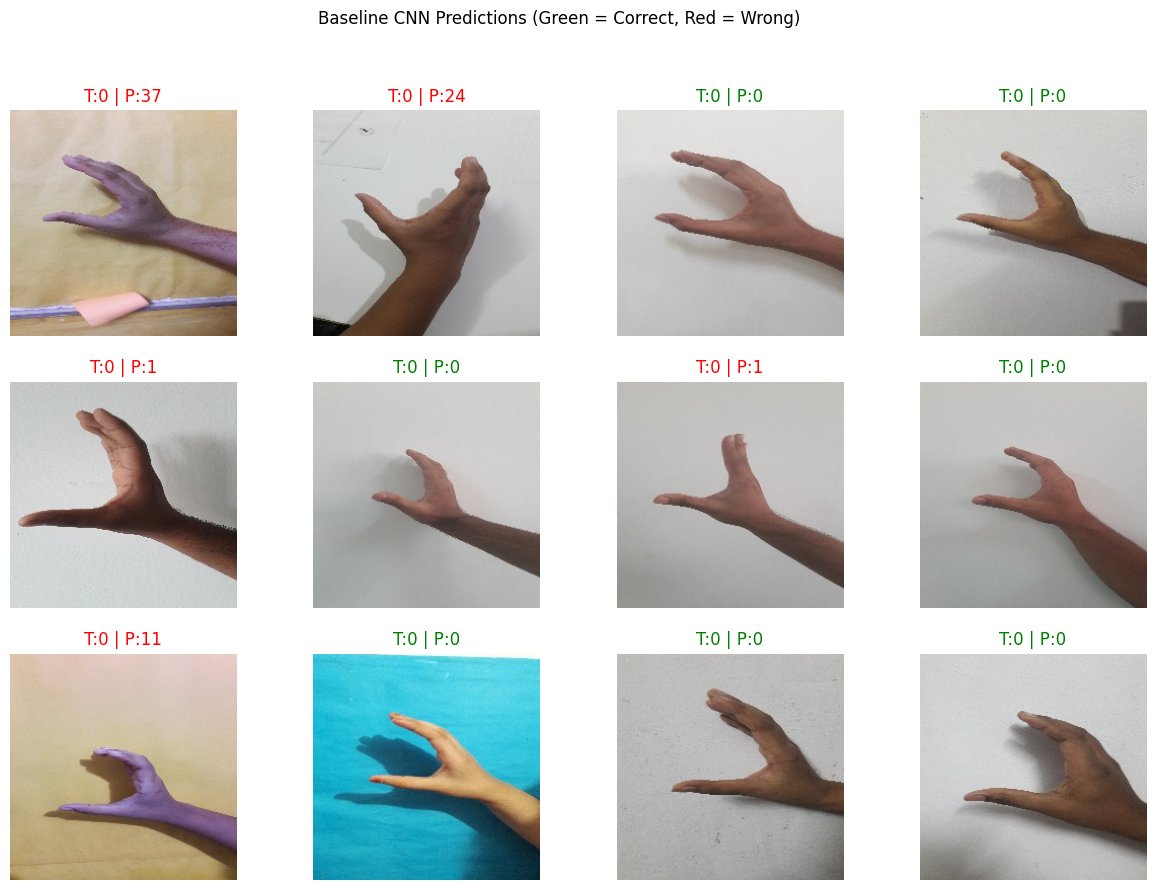

In [22]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = next(val_generator)

pred_probs = model.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

    color = "green" if pred_labels[i] == true_labels[i] else "red"
    class_names = list(val_generator.class_indices.keys())
    plt.title(f"T:{class_names[true_labels[i]]} | P:{class_names[pred_labels[i]]}", color=color)

plt.suptitle("Baseline CNN Predictions (Green = Correct, Red = Wrong)")
plt.show()

##**3. Deeper Architecture with Regularization Layer:**

#### 3.1 Model Architecture:

>• Extend the baseline model by modifying the number of filters and layers to build deeper architec- ture{at least double the layer in comparison to baseline model}.

>• Extend the layers introducing the following regularization techniques.
>• Print and analyze the new model summary.

### Data Augmentation Visualization

>Data augmentation was applied to improve model generalization by creating slightly modified versions of the training images. Since this is a sign language dataset, aggressive transformations such as horizontal flipping were avoided because they may change the meaning of hand gestures. Only mild rotation, zoom, translation, and contrast changes were used.

In [23]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
data_augmentation = Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomContrast(0.50),
    layers.RandomBrightness(0.2, value_range=(0, 1))

])


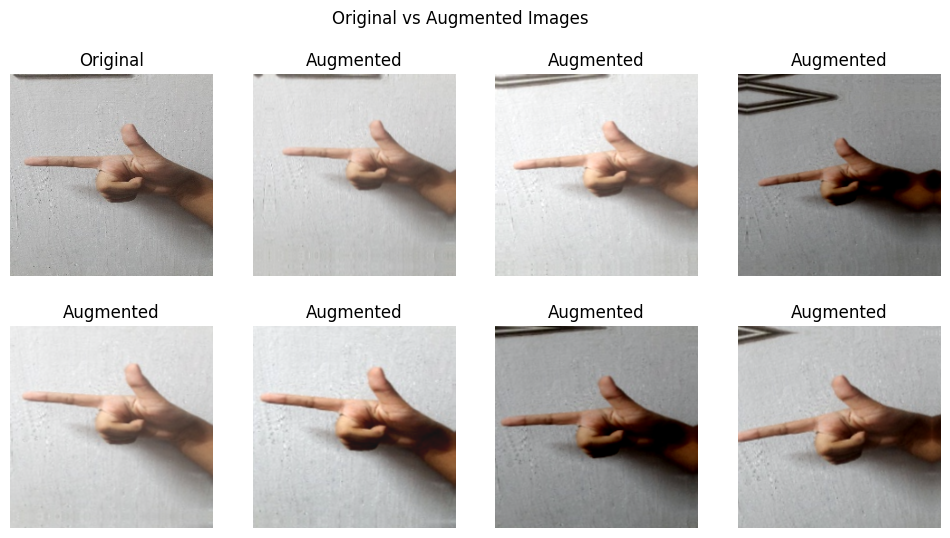

In [24]:
import tensorflow as tf
images, labels = next(train_generator)
sample_image = images[0]

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(sample_image)
plt.axis("off")
plt.title("Original")

for i in range(7):
    augmented_image = data_augmentation(sample_image[None, ...], training=True)
    augmented_image = tf.clip_by_value(augmented_image, 0.0, 1.0)

    plt.subplot(2, 4, i + 2)
    plt.imshow(augmented_image[0])
    plt.axis("off")
    plt.title("Augmented")

plt.suptitle("Original vs Augmented Images")
plt.show()

Model Architecture.

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, Dropout, Flatten, Dense
)

deep_model = Sequential([
    Input(shape=(224, 224, 3)),

    data_augmentation,

    # Block 1: 2 convolutional layers
    Conv2D(32, (3,3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(32, (3,3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2: 2 convolutional layers
    Conv2D(64, (3,3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3,3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3: 2 convolutional layers
    Conv2D(128, (3,3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3,3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Fully connected section
    Flatten(),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.40),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.40),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.30),

    Dense(38, activation='softmax')
])

deep_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 26,024,582 (99.28 MB)

 Trainable params: 26,022,790 (99.27 MB)

 Non-trainable params: 1,792 (7.00 KB)

#### 3.2 Model Training:
• Train the deeper model for an appropriate number of epochs.

• Compare its training time and loss curves against the baseline model

compile deeper model

In [27]:
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
deep_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_deep_model.keras",
        monitor='val_loss',
        save_best_only=True
    )
]

In [29]:
deep_history = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=deep_callbacks
)


Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 107s 394ms/step - accuracy: 0.0548 - loss: 3.7097 - val_accuracy: 0.0435 - val_loss: 3.6240
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 90s 382ms/step - accuracy: 0.1043 - loss: 3.3856 - val_accuracy: 0.1800 - val_loss: 3.0624
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 377ms/step - accuracy: 0.1399 - loss: 3.1689 - val_accuracy: 0.2115 - val_loss: 2.8347
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 89s 378ms/step - accuracy: 0.1851 - loss: 2.9401 - val_accuracy: 0.3304 - val_loss: 2.3565
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 92s 391ms/step - accuracy: 0.2347 - loss: 2.6856 - val_accuracy: 0.4100 - val_loss: 2.1262
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 121s 512ms/step - accuracy: 0.2921 - loss: 2.4499 - val_accuracy: 0.4794 - val_loss: 1.8546
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 120s 510ms/step - accuracy: 0.3397 - loss: 2.2306 - val_accuracy: 0.5571 - val_loss: 1.5360
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 83s 351ms/step - accuracy: 0.3803 - loss

####Train vs Validation plots

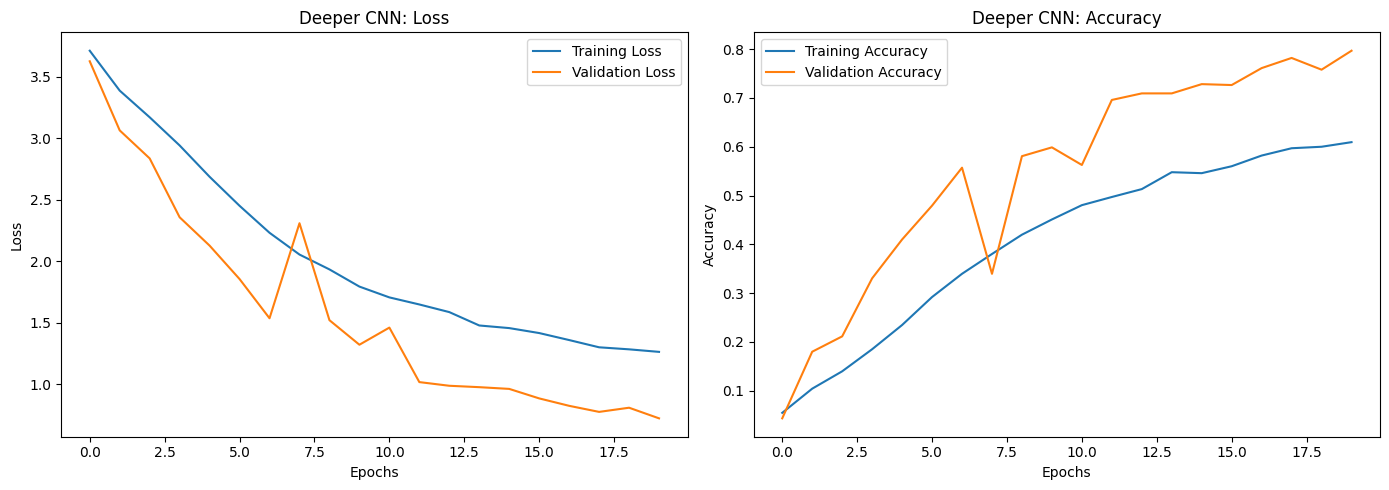

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(deep_history.history['loss'], label='Training Loss')
plt.plot(deep_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Deeper CNN: Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(deep_history.history['accuracy'], label='Training Accuracy')
plt.plot(deep_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Deeper CNN: Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


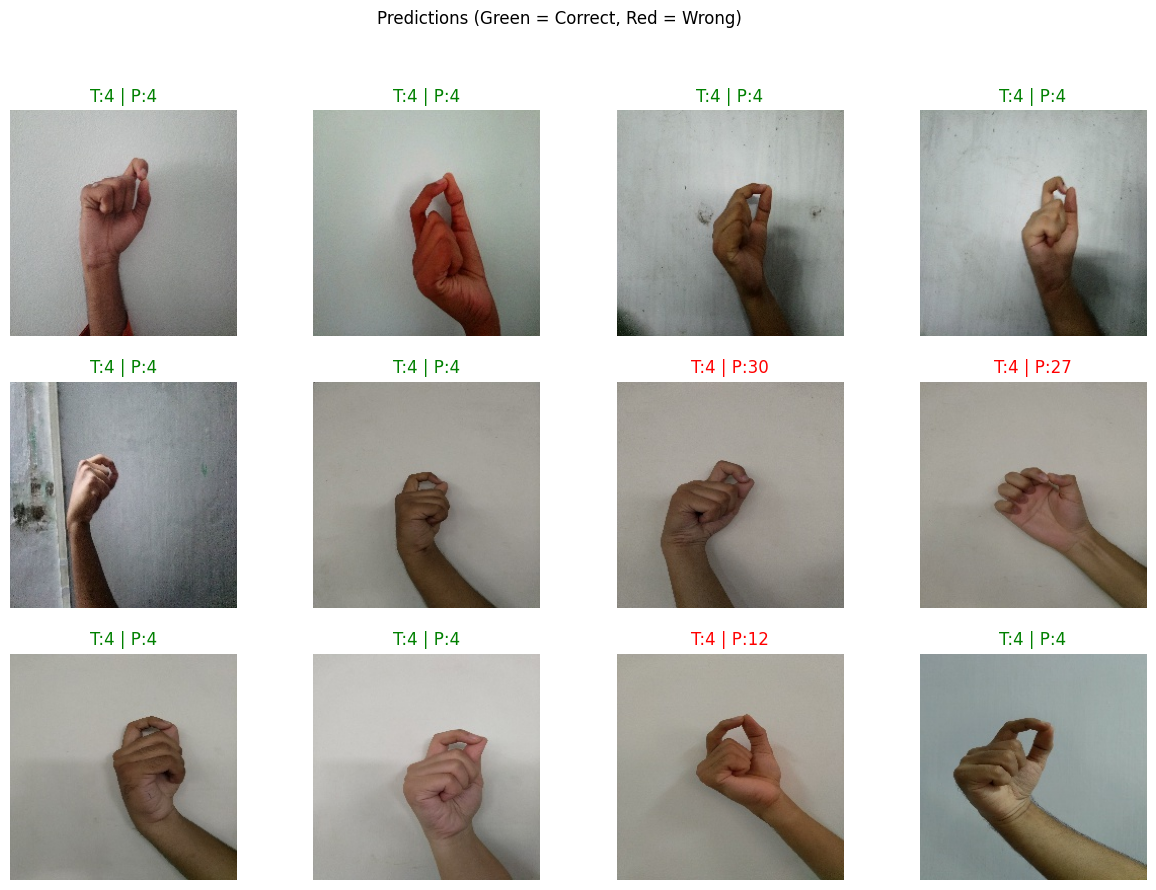

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# val_generator.reset()
images, labels = next(val_generator)

pred_probs = deep_model.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.axis("off")

    if pred_labels[i] == true_labels[i]:
        color = "green"
    else:
        color = "red"

    plt.title(f"T:{true_labels[i]} | P:{pred_labels[i]}", color=color)

plt.suptitle("Predictions (Green = Correct, Red = Wrong)")
plt.show()

####3.3 Model Evaluation:
• Evaluate the deeper model on the same performance metrics as the baseline model.

• Discuss improvements (or lack thereof) compared to the baseline model.


validataion metrics

In [43]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

val_generator.reset()

y_true = val_generator.classes
y_pred_probs = deep_model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step
              precision    recall  f1-score   support

           0       0.84      0.74      0.79        57
           1       0.78      0.88      0.83        58
           2       0.88      0.88      0.88        58
           3       0.87      0.82      0.85        57
           4       0.71      0.82      0.76        56
           5       0.50      0.89      0.64        56
           6       0.68      0.91      0.78        54
           7       0.81      0.59      0.68        58
           8       0.90      0.91      0.91        58
           9       0.96      0.84      0.90        57
          10       0.62      0.43      0.51        58
          11       0.70      0.36      0.48        58
          12       0.94      0.88      0.91        58
          13       0.77      0.88      0.82        57
          14       0.82      0.89      0.86        57
          15       0.82      0.86      0.84        58
          16       0.52      0.49      0.

In [46]:
#TEST EVALUATION

test_loss, test_acc = deep_model.evaluate(test_generator)
print("Deep Model Test Accuracy:", test_acc)
print("Deep Model Test Loss:", test_loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7836 - loss: 0.7341
Deep Model Test Accuracy: 0.783561646938324
Deep Model Test Loss: 0.7341271638870239


The deeper CNN with regularization significantly outperformed the baseline model. Validation accuracy improved from approximately 58% to nearly 80%, while test accuracy increased from 58.08% to 78.36%. Unlike the baseline model, the deeper architecture showed much better generalization performance. The use of batch normalization, dropout, and data augmentation helped reduce overfitting and improved feature learning. Validation loss consistently decreased throughout training, indicating stable optimization. Although the deeper model required significantly longer training time and higher computational cost, it achieved substantially better classification performance across most classes.

###**4. Experimentation and Comparative Analysis:**

####**4.1. Baseline vs. Deeper Model Performance:**
• Compare classification accuracy, loss, and evaluation metrics.

• Discuss whether adding more layers and filters improved performance.


####Comparison of performance
 >The baseline CNN achieved a validation accuracy of approximately 58% with a test accuracy of 58.08%. However, the model showed clear overfitting, as the training accuracy increased to above 90% while validation performance improved only slightly. Validation loss also increased after several epochs, indicating poor generalization.

  >In contrast, the deeper CNN with regularization achieved significantly better performance, reaching approximately 79.69% validation accuracy and 78.36% test accuracy with a substantially lower validation loss. Unlike the baseline model, the deeper CNN maintained a smaller gap between training and validation performance, indicating improved generalization and reduced overfitting.

####Evaluation Metrics Comparison
>The deeper CNN achieved significantly higher precision, recall, and F1-scores across most classes compared to the baseline CNN. The baseline model achieved weighted and macro F1-scores of approximately 0.52, whereas the deeper CNN improved these values to approximately 0.80. Furthermore, the confusion matrix of the deeper model contained more correct predictions along the diagonal, indicating stronger class-wise classification performance and better discrimination between visually similar sign language gestures.

####Effect of Adding More Layers and Filters

>Increasing the number of convolutional layers from 3 to 6 and using larger filter depths (32 → 64 → 128) enabled the deeper CNN to learn more complex and hierarchical image features. In addition, the inclusion of batch normalization, dropout, and data augmentation significantly improved model generalization and reduced overfitting. These regularization techniques helped stabilize training and improved the model’s ability to classify unseen hand gesture images more accurately.

####Final Conclusion

>Overall, the deeper CNN significantly outperformed the baseline CNN in terms of validation accuracy, test accuracy, loss reduction, and evaluation metrics. Although the deeper model required longer training time and higher computational cost, the addition of deeper feature extraction layers and regularization techniques resulted in substantially better generalization and classification performance.

####**4.2. Computational Efficiency:**
• Compare training time and computational cost of the two models.

• Discuss the trade - offs between model complexity and efficiency.


####Training Time Comparison

>The baseline CNN was computationally more efficient, with each epoch taking approximately 18–34 seconds during training. In contrast, the deeper CNN required significantly longer training time, with most epochs taking approximately 80–120 seconds and some epochs exceeding 170 seconds. The increased training time is mainly due to the additional convolutional layers, batch normalization layers, dropout operations, and online data augmentation applied during training

####Computation Cost (Model Complexity)

>According to the model summaries, the baseline CNN contains approximately 22.3 million trainable parameters, while the deeper CNN contains approximately 26 million parameters. Although the deeper model includes substantially more layers and regularization components, the increase in parameter count is relatively moderate because convolutional layers contribute fewer parameters compared to fully connected layers. However, the deeper model still requires more memory, computation, and training time

####Trade-off Between Complexity and Efficiency

>There is a clear trade-off between computational efficiency and model performance. The baseline CNN trains much faster and requires fewer computational resources, but it suffers from severe overfitting and lower classification accuracy. In contrast, the deeper CNN is computationally more expensive and slower to train, but it achieves significantly better validation accuracy, test accuracy, and generalization performance. Therefore, the additional computational cost of the deeper architecture is justified by the substantial improvement in classification performance and model robustness.

####**4.3. Optimizer Analysis: SGD vs Adam:**
• Train the deeper model with SGD and then Adam.

• Compare the impact of these optimizers on convergence speed and final performance.

In [47]:
def build_deep_model():
    model = Sequential([
        Input(shape=(224, 224, 3)),

        data_augmentation,

        Conv2D(32, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(32, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(64, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(64, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(128, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(128, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Flatten(),

        Dense(256, activation=None),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.40),

        Dense(128, activation=None),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.40),

        Dense(64, activation=None),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.30),

        Dense(38, activation='softmax')
    ])

    return model

In [48]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

deep_model_sgd = build_deep_model()

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_deep_model_sgd.keras", monitor='val_loss', save_best_only=True)
]

sgd_history = deep_model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=sgd_callbacks
)

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 90s 362ms/step - accuracy: 0.0553 - loss: 3.6638 - val_accuracy: 0.0338 - val_loss: 3.6196
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 81s 343ms/step - accuracy: 0.1006 - loss: 3.3873 - val_accuracy: 0.0319 - val_loss: 3.6846
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 84s 351ms/step - accuracy: 0.1266 - loss: 3.2020 - val_accuracy: 0.0768 - val_loss: 3.5304
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 87s 369ms/step - accuracy: 0.1611 - loss: 3.0312 - val_accuracy: 0.1874 - val_loss: 2.9177
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - accuracy: 0.2004 - loss: 2.8403 - val_accuracy: 0.2531 - val_loss: 2.6458
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 80s 337ms/step - accuracy: 0.2387 - loss: 2.6476 - val_accuracy: 0.1634 - val_loss: 2.9465
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 87s 368ms/step - accuracy: 0.2803 - loss: 2.4700 - val_accuracy: 0.3919 - val_loss: 2.1376
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 80s 339ms/step - accuracy: 0.3182 - loss: 2

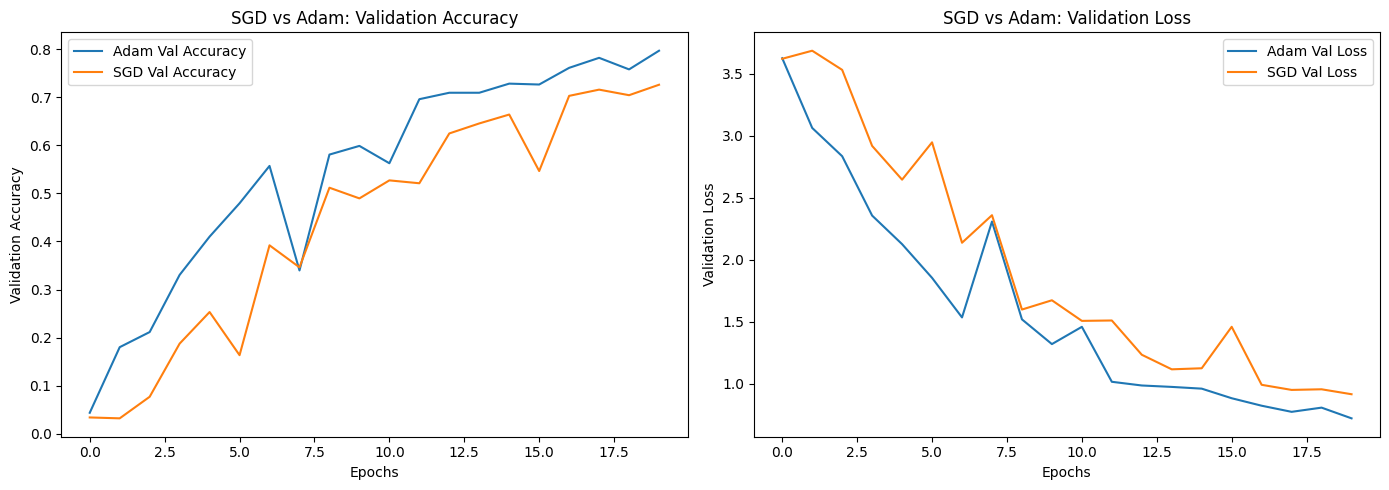

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(deep_history.history['val_accuracy'], label='Adam Val Accuracy')
plt.plot(sgd_history.history['val_accuracy'], label='SGD Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('SGD vs Adam: Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deep_history.history['val_loss'], label='Adam Val Loss')
plt.plot(sgd_history.history['val_loss'], label='SGD Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('SGD vs Adam: Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [64]:
# SGD MODEL TEST EVALUATION

test_generator.reset()

sgd_test_loss, sgd_test_acc = deep_model_sgd.evaluate(test_generator)

print("SGD Test Accuracy:", sgd_test_acc)
print("SGD Test Loss:", sgd_test_loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7333 - loss: 0.9072
SGD Test Accuracy: 0.7333333492279053
SGD Test Loss: 0.9071805477142334


####Adam converged faster and reached better final validation performance than SGD. SGD improved steadily but was slower and less stable, especially in early epochs. Adam achieved higher validation accuracy and lower validation loss by epoch 20.

**4.4. Ablation Study:**

• Remove one component (e.g., dropout or batch normalization).

 • Analyze how performance changes.


Removing dropout , model without dropout

In [50]:
def build_deep_model_no_dropout():
    model = Sequential([
        Input(shape=(224, 224, 3)),

        data_augmentation,

        Conv2D(32, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(32, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(64, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(128, (3,3), padding='same', activation=None),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),

        Flatten(),

        Dense(256, activation=None),
        BatchNormalization(),
        Activation('relu'),

        Dense(128, activation=None),
        BatchNormalization(),
        Activation('relu'),

        Dense(64, activation=None),
        BatchNormalization(),
        Activation('relu'),

        Dense(38, activation='softmax')
    ])

    return model

complie and train

In [51]:
no_dropout_model = build_deep_model_no_dropout()

no_dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

no_dropout_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_no_dropout_model.keras", monitor='val_loss', save_best_only=True)
]

no_dropout_history = no_dropout_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=no_dropout_callbacks
)

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 88s 346ms/step - accuracy: 0.1131 - loss: 3.4038 - val_accuracy: 0.0282 - val_loss: 3.8309
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 80s 338ms/step - accuracy: 0.2635 - loss: 2.7152 - val_accuracy: 0.1754 - val_loss: 3.0442
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 80s 339ms/step - accuracy: 0.4404 - loss: 2.0188 - val_accuracy: 0.2291 - val_loss: 2.8279
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 82s 339ms/step - accuracy: 0.5548 - loss: 1.5403 - val_accuracy: 0.4415 - val_loss: 1.8300
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 80s 339ms/step - accuracy: 0.6437 - loss: 1.2469 - val_accuracy: 0.6414 - val_loss: 1.2064
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 73s 310ms/step - accuracy: 0.6729 - loss: 1.0906 - val_accuracy: 0.5794 - val_loss: 1.3917
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 73s 309ms/step - accuracy: 0.7101 - loss: 0.9665 - val_accuracy: 0.5558 - val_loss: 1.4281
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 79s 335ms/step - accuracy: 0.7300 - loss: 0

**plotcomparison**

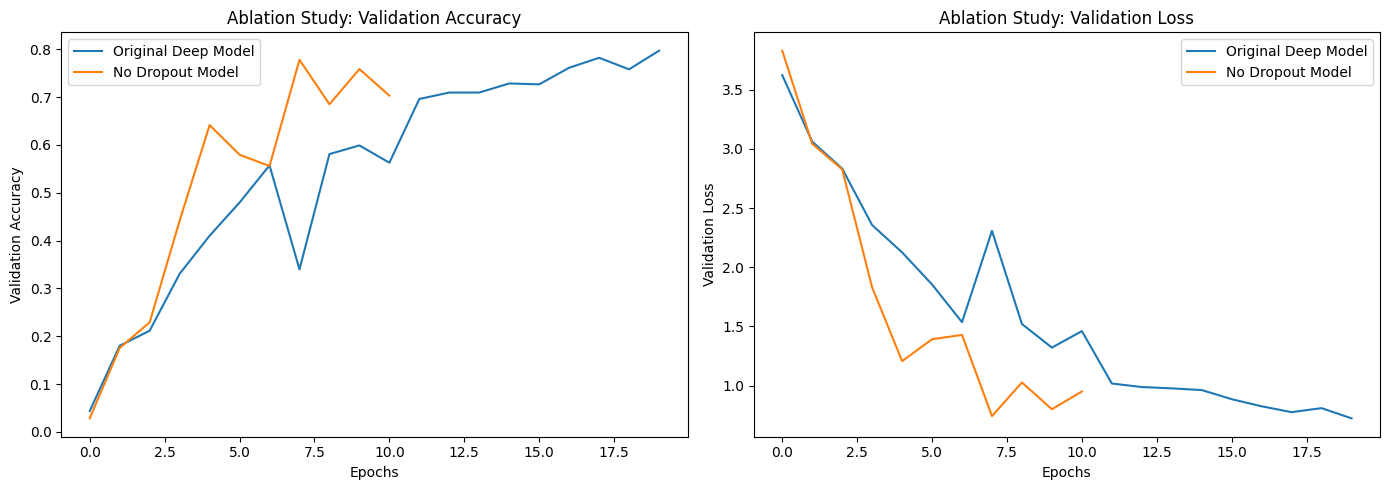

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(deep_history.history['val_accuracy'], label='Original Deep Model')
plt.plot(no_dropout_history.history['val_accuracy'], label='No Dropout Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Ablation Study: Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(deep_history.history['val_loss'], label='Original Deep Model')
plt.plot(no_dropout_history.history['val_loss'], label='No Dropout Model')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Ablation Study: Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

**test evaluation**

In [53]:
test_loss, test_acc = no_dropout_model.evaluate(test_generator)
print("No Dropout Test Accuracy:", test_acc)
print("No Dropout Test Loss:", test_loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7644 - loss: 0.7479
No Dropout Test Accuracy: 0.7643835544586182
No Dropout Test Loss: 0.7479023337364197


####The ablation study showed that removing dropout increased training accuracy and allowed the model to learn faster during the early epochs. However, the no-dropout model achieved lower validation and test accuracy compared to the original deeper model with dropout. In addition, the validation performance became less stable and training stopped earlier due to EarlyStopping. These results indicate that dropout slightly reduces training performance but improves generalization and robustness on unseen data. Therefore, dropout was beneficial for reducing overfitting in the deeper CNN architecture.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


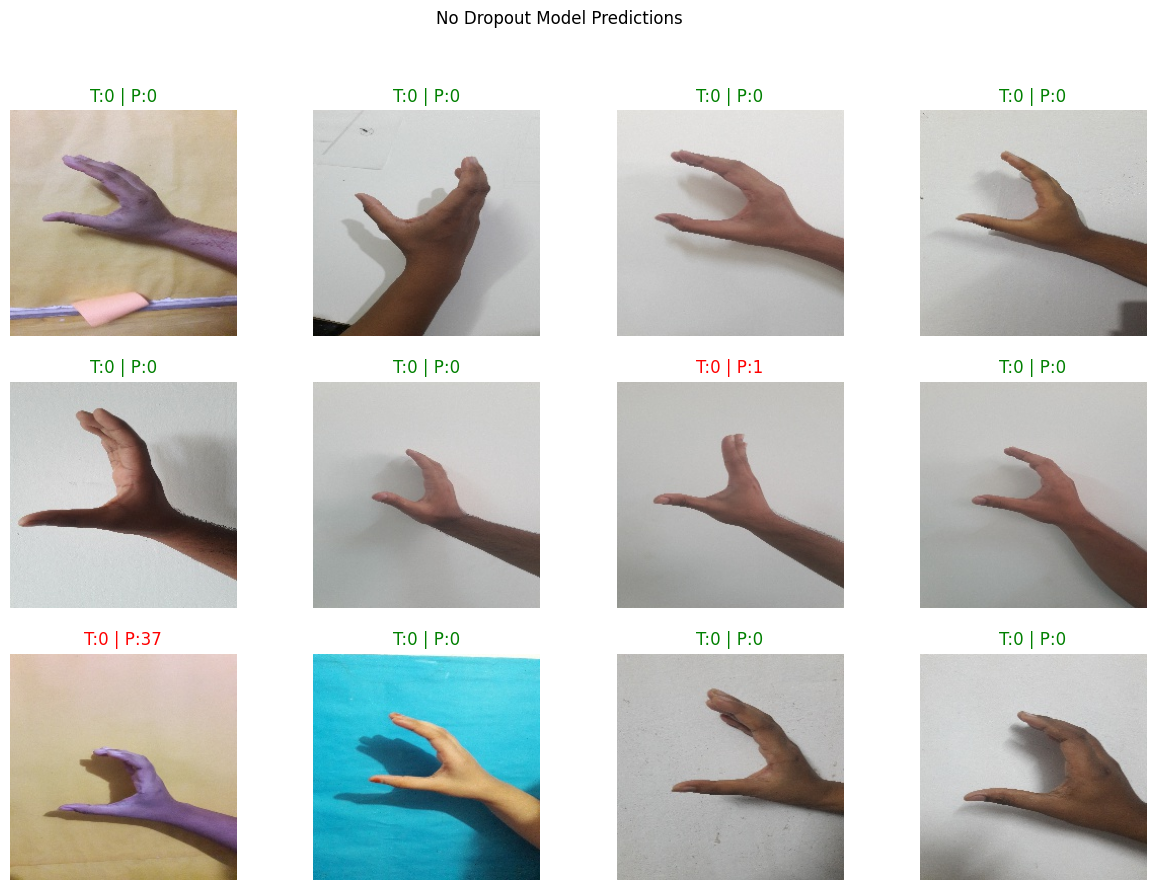

In [54]:
images, labels = next(val_generator)

pred_probs = no_dropout_model.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15,10))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

    color = "green" if pred_labels[i] == true_labels[i] else "red"
    plt.title(f"T:{true_labels[i]} | P:{pred_labels[i]}", color=color)

plt.suptitle("No Dropout Model Predictions")
plt.show()

**4.5 Challenges and Observations:**

• Discuss any difficulties faced, such as overfitting and underfitting.

• Report the total training time for deeper architecture.

• Mention if hardware acceleration (e.g. Google Colab, with GPU/TPU was used.



One of the main challenges encountered during the project was overfitting in the baseline CNN model. The baseline architecture achieved very high training accuracy but significantly lower validation accuracy, indicating poor generalization to unseen data. This issue occurred because the model contained a large number of trainable parameters without any regularization techniques.

To address this problem, a deeper CNN architecture with batch normalization, dropout, and data augmentation was implemented. These regularization techniques improved validation and test performance significantly and reduced overfitting. Another observation was that removing dropout increased training accuracy but reduced generalization performance, confirming the importance of dropout for model robustness.

The deeper CNN model required substantially longer training time compared to the baseline model. The baseline model required approximately 2–3 minutes of total training time, while the deeper CNN required approximately 30–35 minutes to complete 20 epochs due to the increased architectural complexity and online data augmentation.

Training was performed using Google Colab with NVIDIA T4 GPU acceleration, which significantly reduced training time compared to CPU-based execution.

#**5. Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)**

##**Loading and Adapting a Pre - Trained Model:**

  Select an appropriate pre - trained CNN model (e.g. VGG, ResNet, Incpetion) based on the character- stics of your dataset.

  • Load the pre - trained model using keras.

  • Modify the model architecture to fit your specific classification task.

  – Remove the original fully connected layers.

  – Add a new dense layers tailored to your dataset’s number of classes.

  • Choose whether to freeze certain layers or fine - tune the entire model based on your dataset size and
  computational constraints.

In [56]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pretrained MobileNetV2 without original classification head
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained convolutional base
base_model.trainable = False

# Add custom classification head for 38 classes
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(38, activation='softmax')(x)

transfer_model = Model(inputs, outputs)

transfer_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##**Model Training and Fine - Tuning:**

1. Training Strategies:

• Feature Extraction:

– Freeze the convolutional base of the pre - trained model to retain previously learned feature representations.

– Train only the newly added layers for classification. • Fine - Tuning:

– Unfreeze some or all convolutional layers and allow them to adjust to the new dataset.

– This approach requires a lower learning rate to avoid overfitting and catastrophic forgetting.

In [57]:
#feature extraciton
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_transfer_model.keras", monitor='val_loss', save_best_only=True)
]

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=transfer_callbacks
)

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 62s 187ms/step - accuracy: 0.3389 - loss: 2.3377 - val_accuracy: 0.6330 - val_loss: 1.3215
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.5963 - loss: 1.2788 - val_accuracy: 0.7173 - val_loss: 0.9543
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.6821 - loss: 0.9964 - val_accuracy: 0.7584 - val_loss: 0.8001
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.7257 - loss: 0.8411 - val_accuracy: 0.7760 - val_loss: 0.7438
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.7593 - loss: 0.7422 - val_accuracy: 0.7691 - val_loss: 0.7300
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.7886 - loss: 0.6635 - val_accuracy: 0.7922 - val_loss: 0.6797
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.7971 - loss: 0.6041 - val_accuracy: 0.7899 - val_loss: 0.6552
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.8189 - loss: 0.5594 -

In [58]:
#fine tune- unfreezing top-layer
base_model.trainable = True

# Freeze most layers, unfreeze last ~30
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [59]:
#recomplie with low learnign rate
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [60]:
#continue training
fine_tune_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=14,
    callbacks=transfer_callbacks
)

Epoch 1/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 51s 139ms/step - accuracy: 0.6311 - loss: 1.1400 - val_accuracy: 0.8033 - val_loss: 0.6223
Epoch 2/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.7463 - loss: 0.7687 - val_accuracy: 0.8195 - val_loss: 0.5722
Epoch 3/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7968 - loss: 0.6216 - val_accuracy: 0.8265 - val_loss: 0.5425
Epoch 4/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.8239 - loss: 0.5227 - val_accuracy: 0.8343 - val_loss: 0.5049
Epoch 5/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8450 - loss: 0.4638 - val_accuracy: 0.8417 - val_loss: 0.4848
Epoch 6/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.8588 - loss: 0.4194 - val_accuracy: 0.8427 - val_loss: 0.4793
Epoch 7/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8773 - loss: 0.3664 - val_accuracy: 0.8556 - val_loss: 0.4612
Epoch 8/14
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.8938 - loss: 0.3279 -

2.6.3 Model Evaluation and Prediction:
• Evaluate the fine tuned model using the same performance metrics as in Part A.
• Make predictions on test data and compare results with the baseline and deeper models from Part A. • Discuss whether transfer learning outperforms training from scratch for your dataset.

In [61]:
#validation metrics
val_generator.reset()

y_true = val_generator.classes
y_pred_probs = transfer_model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        57
           1       0.91      0.90      0.90        58
           2       0.94      0.83      0.88        58
           3       0.92      0.86      0.89        57
           4       0.89      0.84      0.86        56
           5       0.87      0.82      0.84        56
           6       0.83      0.83      0.83        54
           7       0.87      0.78      0.82        58
           8       0.88      0.91      0.90        58
           9       0.89      0.84      0.86        57
          10       0.76      0.76      0.76        58
          11       0.88      0.88      0.88        58
          12       0.92      0.97      0.94        58
          13       0.96      0.96      0.96        57
          14       0.88      0.93      0.91        57
          15       0.80      0.81      0.80        58
          16       0.77      0.77      

In [62]:
#test evaluation (final result)
test_loss, test_acc = transfer_model.evaluate(test_generator)

print("Transfer Model Test Accuracy:", test_acc)
print("Transfer Model Test Loss:", test_loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 377ms/step - accuracy: 0.8822 - loss: 0.4105
Transfer Model Test Accuracy: 0.8821917772293091
Transfer Model Test Loss: 0.41047555208206177


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


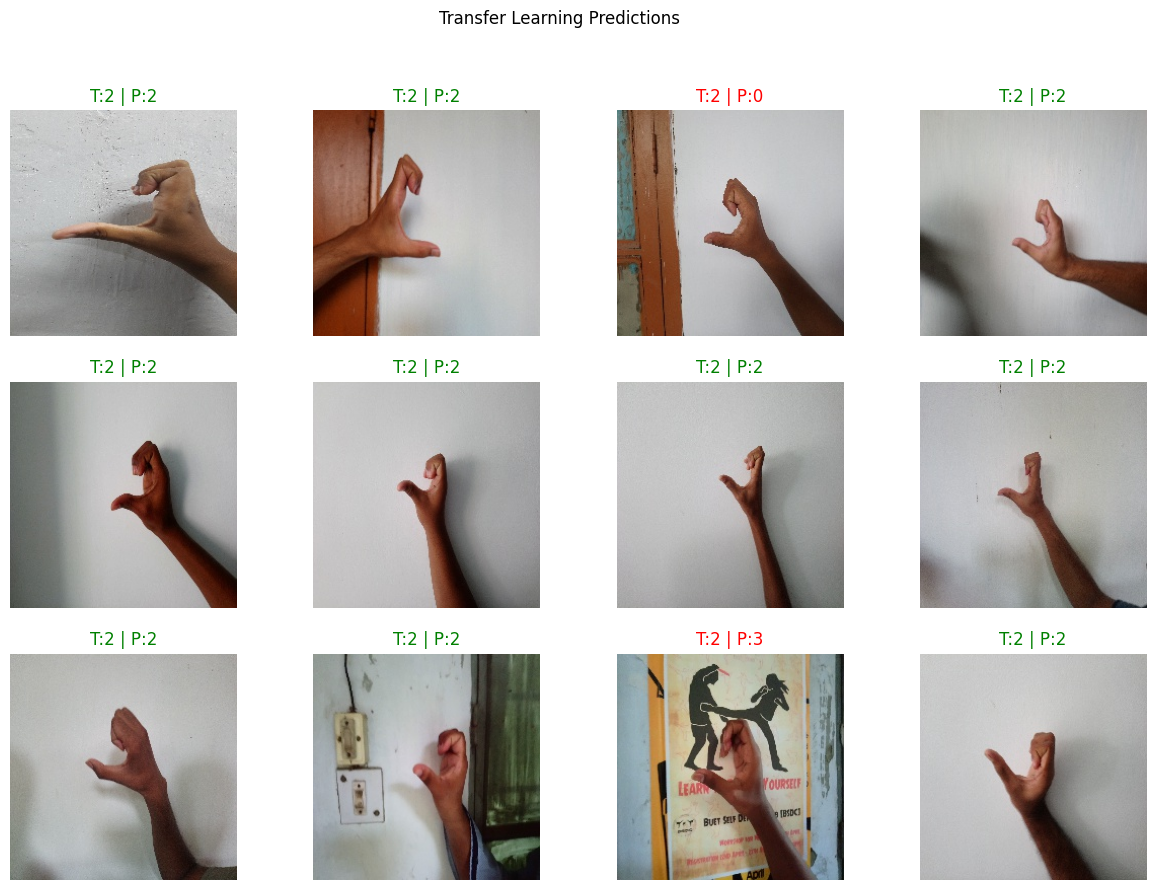

In [68]:
#prediction visulaization
images, labels = next(val_generator)

pred_probs = transfer_model.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(15,10))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

    color = "green" if pred_labels[i] == true_labels[i] else "red"
    plt.title(f"T:{true_labels[i]} | P:{pred_labels[i]}", color=color)

plt.suptitle("Transfer Learning Predictions")
plt.show()

* Baseline CNN test accuracy: 58.08%
* Deeper CNN test accuracy: 78.36%
* SGD deeper CNN test accuracy: 73.33%
* No-dropout model test accuracy: 76.44%
* Transfer MobileNetV2 test accuracy: 88.22%

Transfer learning outperformed both the baseline CNN and the deeper CNN trained from scratch. The fine-tuned MobileNetV2 model achieved the highest test accuracy of 88.22% and the best validation F1-score of 0.88. This shows that pretrained ImageNet features helped the model learn stronger visual representations and generalize better on the sign language dataset.